In [46]:
import cv2
import numpy as np

img = cv2.imread('../angio-6/86.png', cv2.IMREAD_GRAYSCALE)
cv2.imshow('Original', img)
cv2.waitKey(0)

-1

In [4]:
contours = cv2.imread('../angio-6/contours.png', cv2.IMREAD_COLOR)
cv2.imshow('Contours', contours)
cv2.waitKey(0)

-1

In [53]:
file_points = []

def add_points(filepath, points):
    result = points
    f = open(filepath, 'r')
    lines = f.readlines()
    for l in lines:
        i,j = map(float, l.split())
        i = int(i)
        j = int(j)
        result.append([i,j])
    
    return result

file_points = add_points('../angio-6/86_left.txt', file_points)
file_points = add_points('../angio-6/86_right.txt', file_points)
points = np.array(file_points)

In [72]:
img2paint = img.copy()
img2paint = cv2.cvtColor(img2paint, cv2.COLOR_GRAY2BGR)

for p in points:
    img2paint = cv2.circle(img2paint,p,0,(0,255,0),1)

cv2.imshow('asd', img2paint)
cv2.waitKey(0)

-1

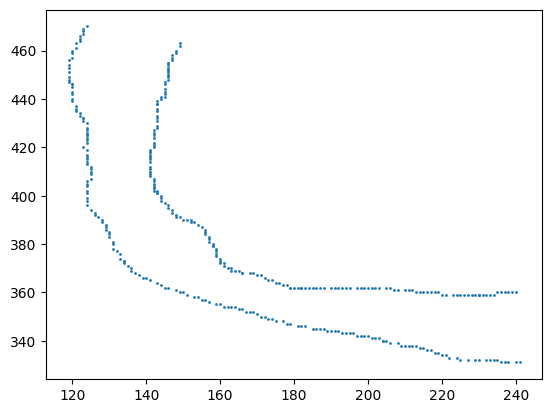

In [57]:
import matplotlib.pyplot as plt

plt.scatter(points[:, 0], points[:, 1],s=1)
plt.show()

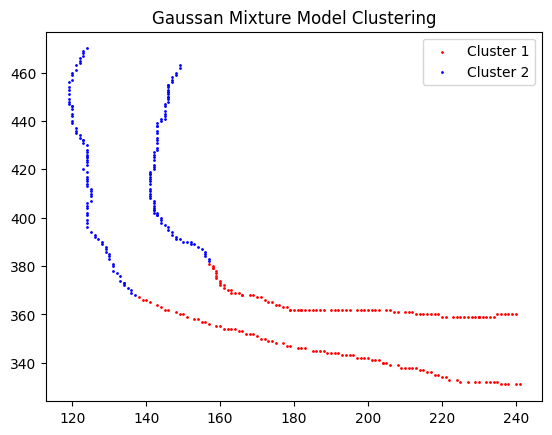

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2)
labels = gmm.fit_predict(points)
cluster1 = []
cluster2 = []

for i in range(len(points)):
    if labels[i] == 0:
        cluster1.append(points[i])
    else:
        cluster2.append(points[i])

cluster1 = np.array(cluster1)
cluster2 = np.array(cluster2)

# Визуализация
plt.scatter(cluster1[:, 0], cluster1[:, 1], color='red', label='Cluster 1', s=1)
plt.scatter(cluster2[:, 0], cluster2[:, 1], color='blue', label='Cluster 2', s=1)
plt.title("Gaussan Mixture Model Clustering")
plt.legend()
plt.show()

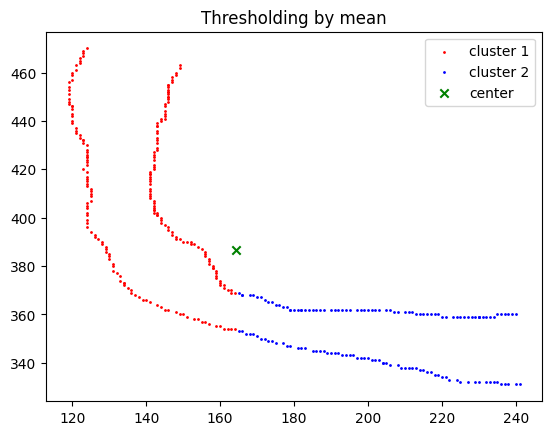

In [71]:
import numpy as np
import matplotlib.pyplot as plt

center = np.mean(points, axis=0)
left_points = points[points[:, 0] < center[0]]
right_points = points[points[:, 0] > center[0]]

plt.scatter(left_points[:, 0], left_points[:, 1], color='red', label='cluster 1', s=1)
plt.scatter(right_points[:, 0], right_points[:, 1], color='blue', label='cluster 2', s=1)
plt.scatter(center[0], center[1], color='green', marker='x', label='center')
plt.legend()
plt.title("Thresholding by mean")
plt.show()

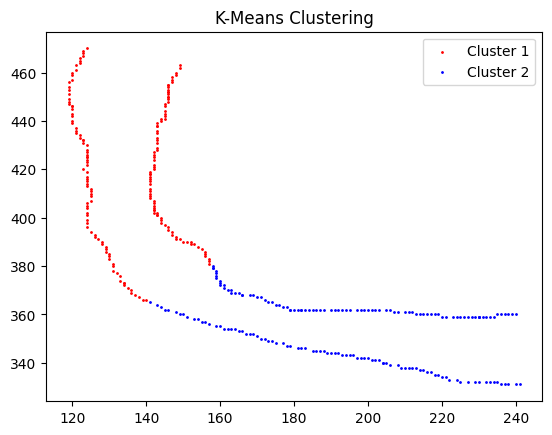

In [60]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=2)
kmeans.fit(points)
labels = kmeans.labels_

cluster1 = []
cluster2 = []

for i in range(len(points)):
    if labels[i] == 0:
        cluster1.append(points[i])
    else:
        cluster2.append(points[i])

cluster1 = np.array(cluster1)
cluster2 = np.array(cluster2)

# Визуализация
plt.scatter(cluster1[:, 0], cluster1[:, 1], color='red', label='Cluster 1', s=1)
plt.scatter(cluster2[:, 0], cluster2[:, 1], color='blue', label='Cluster 2', s=1)
plt.title("K-Means Clustering")
plt.legend()
plt.show()

c:\soft\miniconda\envs\VCD\lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


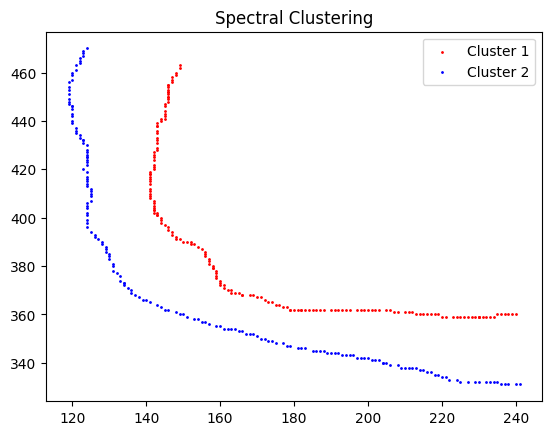

In [70]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=6,
    random_state=42,
     n_jobs=-1,
)

labels = spectral.fit_predict(points)

cluster1 = []
cluster2 = []

for i in range(len(points)):
    if labels[i] == 0:
        cluster1.append(points[i])
    else:
        cluster2.append(points[i])

cluster1 = np.array(cluster1)
cluster2 = np.array(cluster2)

plt.scatter(cluster1[:, 0], cluster1[:, 1], color='red', label='Cluster 1', s=1)
plt.scatter(cluster2[:, 0], cluster2[:, 1], color='blue', label='Cluster 2', s=1)
plt.title("Spectral Clustering")
plt.legend()
plt.show()

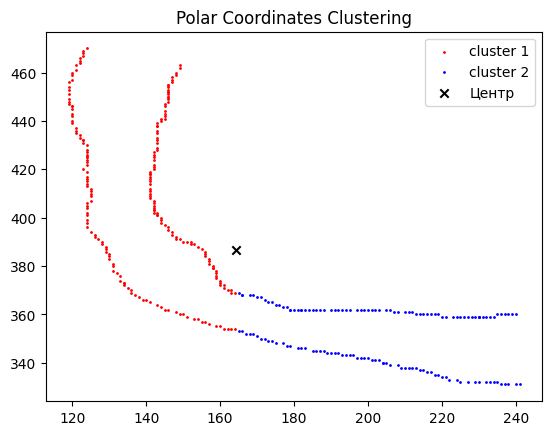

In [69]:
import numpy as np
import matplotlib.pyplot as plt

center = np.mean(points, axis=0)
dx = points[:, 0] - center[0]
dy = points[:, 1] - center[1]
angles = np.arctan2(dy, dx)

left_mask = (angles >= np.pi/2) | (angles <= -np.pi/2)
right_mask = ~left_mask

left_points = points[left_mask]
right_points = points[right_mask]

plt.scatter(left_points[:, 0], left_points[:, 1], c='red', label='cluster 1', s=1)
plt.scatter(right_points[:, 0], right_points[:, 1], c='blue', label='cluster 2', s=1)
plt.scatter(center[0], center[1], c='black', marker='x', label='Центр')
plt.legend()
plt.title('Polar Coordinates Clustering')
plt.show()